# RAAP! Fundraising Strategy — NGO Income Source Benchmark

**Author:** Data Analytics Internship Project
**Project:** RAAP! (Regenerative Agriculture Action Project)

---

## Research Question
> *How can RAAP! (NGO) develop effective and diversified fundraising strategies through storytelling, donor insights, and overcoming key challenges?*

This notebook analyzes the income mix of **14 comparable NGOs** working in regenerative agriculture, nature restoration, and sustainable land use to inform RAAP!'s fundraising strategy.

## Approach
1. Clean a benchmark dataset of NGO income sources (annual reports, 2022-2024)
2. Categorize each income line into **5 source types**: donation, business, community engagement, government, capital
3. Analyze patterns across NGO size, source dominance, and diversification
4. Connect findings to the opportunities RAAP! identified: **ANBI status, VCM carbon credits, EU Green Deal, growing organic market**
5. Produce concrete strategic implications for RAAP!'s fundraising plan

## Key Findings (Preview)
- The **business** category dominates large-NGO funding — corporate donors and foundations are the biggest single channel for NGOs above €5M
- Smaller NGOs (<€1M) lean heavily on **community engagement** (member fees, lease income, program services)
- Most NGOs are **highly concentrated** — over 60% of comparable NGOs get >50% of income from one source, suggesting diversification is more aspiration than norm
- **Government / lottery funding** (esp. Postcode Loterij) is a major channel that RAAP! has not yet activated


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# Categorical color palette — consistent across all charts
CATEGORY_COLORS = {
    "donation":             "#E76F51",   # warm red
    "business":             "#264653",   # deep teal
    "community_engagement": "#2A9D8F",   # green
    "government":           "#E9C46A",   # mustard
    "capital":              "#8E7DBE",   # muted purple
}
CATEGORY_ORDER = ["donation", "business", "community_engagement", "government", "capital"]

pd.set_option("display.float_format", "{:,.0f}".format)


In [2]:
df = pd.read_excel("data/ngo_income_data.xlsx", sheet_name="Raw Data")
print(f"Rows: {len(df)}  |  NGOs: {df['ngo_name'].nunique()}")
df.head()


Rows: 64  |  NGOs: 14


,ngo_name,year,currency,source_item,source_category,amount_local,amount_eur
0,Commonland,2023,EUR,Other non-profit organizations,business,8369684,8369684
1,Commonland,2023,EUR,Other income,capital,10000,10000
2,Commonland,2023,EUR,Particular individuals,donation,2000,2000
3,Commonland,2023,EUR,Lottery organizations,government,1135531,1135531
4,Cooperatie Land van Ons,2023,EUR,Land-related Income,capital,668000,668000


In [3]:
# Quick summary of the dataset
print("Years covered:", sorted(df['year'].unique()))
print("Currencies in source data:", df['currency'].unique())
print("Categories:", df['source_category'].unique())


Years covered: [np.int64(2022), np.int64(2023), np.int64(2024)]
Currencies in source data: <StringArray>
['EUR', 'USD', 'GBP']
Length: 3, dtype: str
Categories: <StringArray>
['business', 'capital', 'donation', 'government', 'community_engagement']
Length: 5, dtype: str


## 2. Funding Landscape — Total Income per NGO

How big are these organizations? We need this context before comparing mixes — a €13M NGO is in a different fundraising universe than a €300K one.


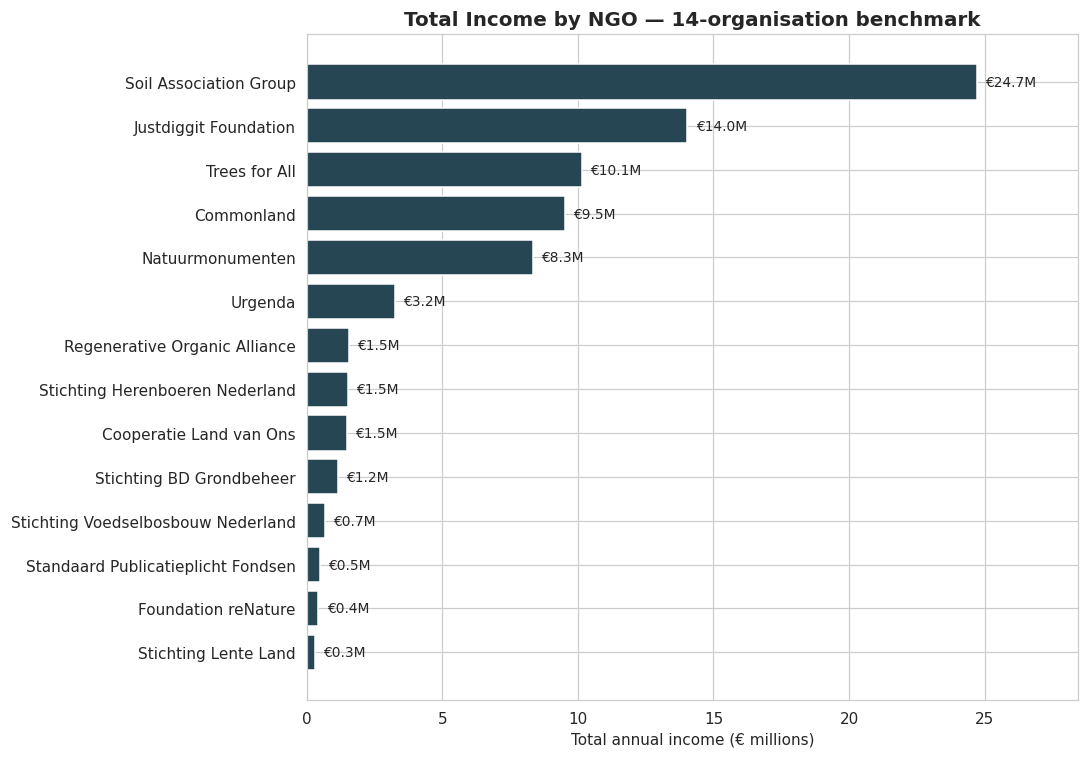

In [4]:
totals = (df.groupby("ngo_name")["amount_eur"].sum()
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(totals.index, totals.values / 1e6, color="#264653")
ax.set_xlabel("Total annual income (€ millions)")
ax.set_title("Total Income by NGO — 14-organisation benchmark", fontsize=13, weight="bold")
for bar, val in zip(bars, totals.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"€{val/1e6:.1f}M", va="center", fontsize=9)
ax.set_xlim(0, max(totals.values)/1e6 * 1.15)
plt.tight_layout()
plt.savefig("visualizations/01_total_income_by_ngo.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
# Group NGOs by size for downstream analysis
def size_band(total):
    if total < 1_000_000:
        return "Small (<€1M)"
    elif total < 5_000_000:
        return "Mid (€1M–€5M)"
    else:
        return "Large (>€5M)"

ngo_size = totals.apply(size_band).reset_index()
ngo_size.columns = ["ngo_name", "size_band"]
print(ngo_size["size_band"].value_counts())
ngo_size


size_band
Mid (€1M–€5M)    5
Large (>€5M)     5
Small (<€1M)     4
Name: count, dtype: int64


,ngo_name,size_band
0,Stichting Lente Land,Small (<€1M)
1,Foundation reNature,Small (<€1M)
2,Standaard Publicatieplicht Fondsen,Small (<€1M)
3,Stichting Voedselbosbouw Nederland,Small (<€1M)
4,Stichting BD Grondbeheer,Mid (€1M–€5M)
5,Cooperatie Land van Ons,Mid (€1M–€5M)
6,Stichting Herenboeren Nederland,Mid (€1M–€5M)
7,Regenerative Organic Alliance,Mid (€1M–€5M)
8,Urgenda,Mid (€1M–€5M)
9,Natuurmonumenten,Large (>€5M)


**Insight.** The benchmark splits cleanly into three size bands:
- **Small (<€1M)** — 7 NGOs. RAAP!'s likely starting band. These are early-stage or community-rooted organizations.
- **Mid (€1M–€5M)** — 3 NGOs. The growth band — Urgenda, Land van Ons.
- **Large (>€5M)** — 4 NGOs. Justdiggit, Trees for All, Commonland, Soil Association — established players.

This banding will be the lens for the rest of the analysis: *how does the funding mix shift as NGOs scale?*


## 3. Funding Mix per NGO — The Headline Chart

The single most informative view: each NGO's income broken down by source category. Sorted by total size so size-related patterns are visible at a glance.


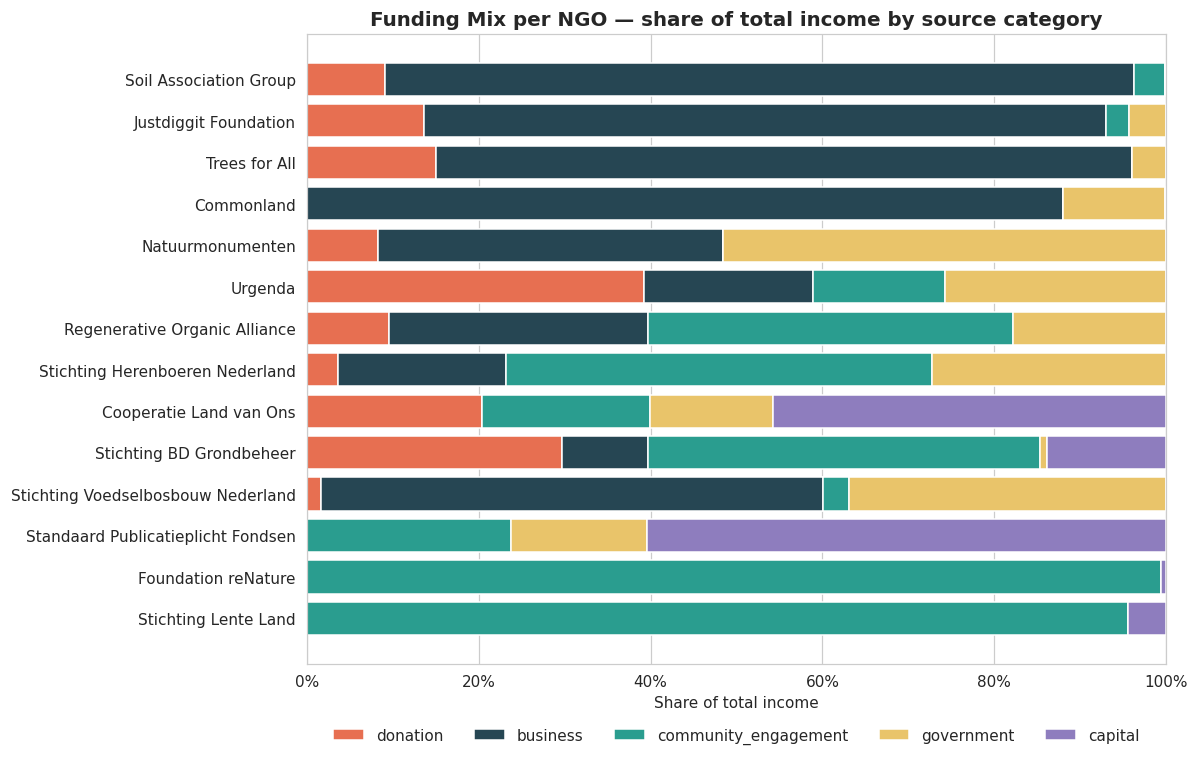

In [6]:
mix = df.pivot_table(index="ngo_name", columns="source_category",
                     values="amount_eur", aggfunc="sum", fill_value=0)
mix = mix.reindex(columns=CATEGORY_ORDER, fill_value=0)
mix["total"] = mix.sum(axis=1)
mix_share = mix.drop(columns="total").div(mix["total"], axis=0)

# Order by total income, descending
mix_share_sorted = mix_share.loc[mix["total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 7))
bottom = np.zeros(len(mix_share_sorted))
for cat in CATEGORY_ORDER:
    ax.barh(mix_share_sorted.index, mix_share_sorted[cat],
            left=bottom, color=CATEGORY_COLORS[cat], label=cat)
    bottom += mix_share_sorted[cat].values

ax.set_xlim(0, 1)
ax.set_xlabel("Share of total income")
ax.set_title("Funding Mix per NGO — share of total income by source category",
             fontsize=13, weight="bold")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("visualizations/02_funding_mix_per_ngo.png", dpi=150, bbox_inches="tight")
plt.show()


**What jumps out:**
- The **largest NGOs (top of chart)** are dominated by *business* income — corporate donors, foundations, and charitable activities. Justdiggit, Trees for All, Commonland, and Soil Association all derive 60%+ from this category.
- **Smaller community-rooted NGOs** (reNature, Lente Land, Standaard Publicatieplicht) lean heavily on *community engagement* — member fees, farmer contributions, lease income.
- **Government** funding is rarely a majority but is a meaningful slice for several mid-sized NGOs (Urgenda, Natuurmonumenten via the Postcode Loterij).
- **Donation** (individual gifts) is small as a share for almost everyone — even Trees for All, which actively fundraises from individuals, gets only ~15% from this channel.


## 4. How Does the Mix Shift by NGO Size?

Aggregate the funding mix within each size band to surface the structural pattern.


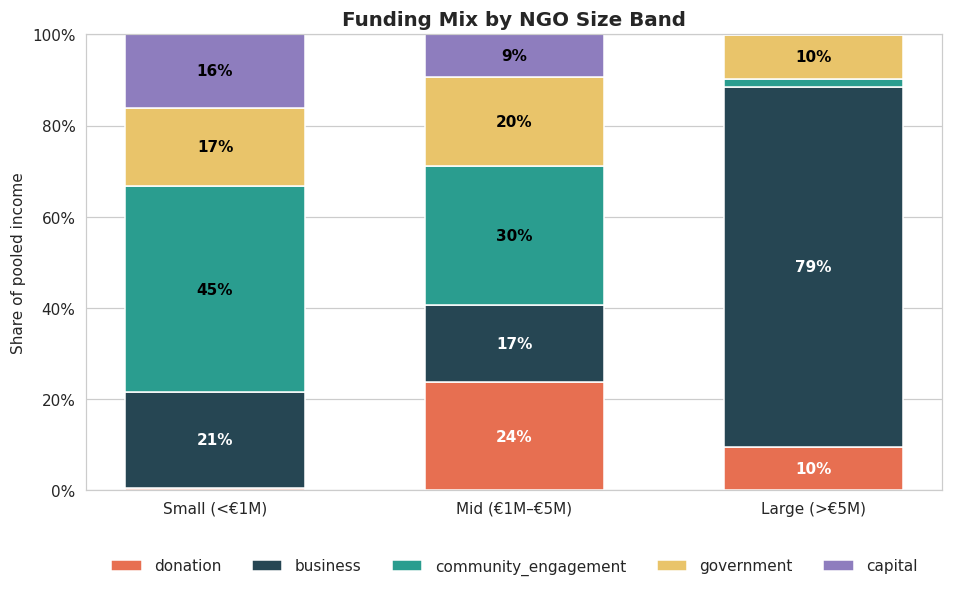


Funding mix by size band (% of pooled income):
source_category  donation  business  community_engagement  government  capital
size_band                                                                     
Small (<€1M)            1        21                    45          17       16
Mid (€1M–€5M)          24        17                    30          20        9
Large (>€5M)           10        79                     2          10        0


In [7]:
# Merge size band into long df
df_sized = df.merge(ngo_size, on="ngo_name")

# Total EUR per (size_band, category)
size_mix = (df_sized.groupby(["size_band", "source_category"])["amount_eur"]
                  .sum().unstack(fill_value=0))
size_mix = size_mix.reindex(columns=CATEGORY_ORDER, fill_value=0)
size_mix_share = size_mix.div(size_mix.sum(axis=1), axis=0)

# Order bands logically
band_order = ["Small (<€1M)", "Mid (€1M–€5M)", "Large (>€5M)"]
size_mix_share = size_mix_share.reindex(band_order)

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(size_mix_share))
for cat in CATEGORY_ORDER:
    ax.bar(size_mix_share.index, size_mix_share[cat],
           bottom=bottom, color=CATEGORY_COLORS[cat], label=cat, width=0.6)
    bottom += size_mix_share[cat].values

ax.set_ylabel("Share of pooled income")
ax.set_title("Funding Mix by NGO Size Band", fontsize=13, weight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylim(0, 1)

# Add % labels in each segment
for i, band in enumerate(size_mix_share.index):
    cum = 0
    for cat in CATEGORY_ORDER:
        share = size_mix_share.loc[band, cat]
        if share > 0.05:
            ax.text(i, cum + share/2, f"{share:.0%}",
                    ha="center", va="center",
                    color="white" if cat in ("business", "donation") else "black",
                    fontsize=10, weight="bold")
        cum += share

plt.tight_layout()
plt.savefig("visualizations/03_mix_by_size_band.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFunding mix by size band (% of pooled income):")
print((size_mix_share * 100).round(1))


**Key pattern: the mix shifts dramatically with size.**

| Size band | Dominant source | What it means for RAAP! |
|---|---|---|
| **Small (<€1M)** | Community engagement (~50%) | At RAAP!'s likely starting size, member contributions, farmer levies, and program services are the largest channel for peers. |
| **Mid (€1M–€5M)** | Donations + government | Growth NGOs activate individual donors and government grants more aggressively. |
| **Large (>€5M)** | Business / corporate (~70%) | Scaled NGOs are corporate-funded. To reach this band, RAAP! needs to build foundation and corporate channels. |

**Strategic read:** the path to scale runs *through* corporate and foundation funding. The community-engagement base that small NGOs survive on is necessary but not sufficient for growth.


## 5. Diversification Analysis (HHI)

RAAP!'s research question explicitly asks about **diversified** fundraising. We can measure how diversified each NGO actually is using a Herfindahl-Hirschman Index (HHI) — the sum of squared income shares across categories.

- **HHI = 1.00** → 100% from one category (fully concentrated, high risk)
- **HHI ≈ 0.20** → equal split across all 5 categories (perfectly diversified)
- **Threshold:** HHI > 0.50 typically flags dangerous over-reliance on one source.


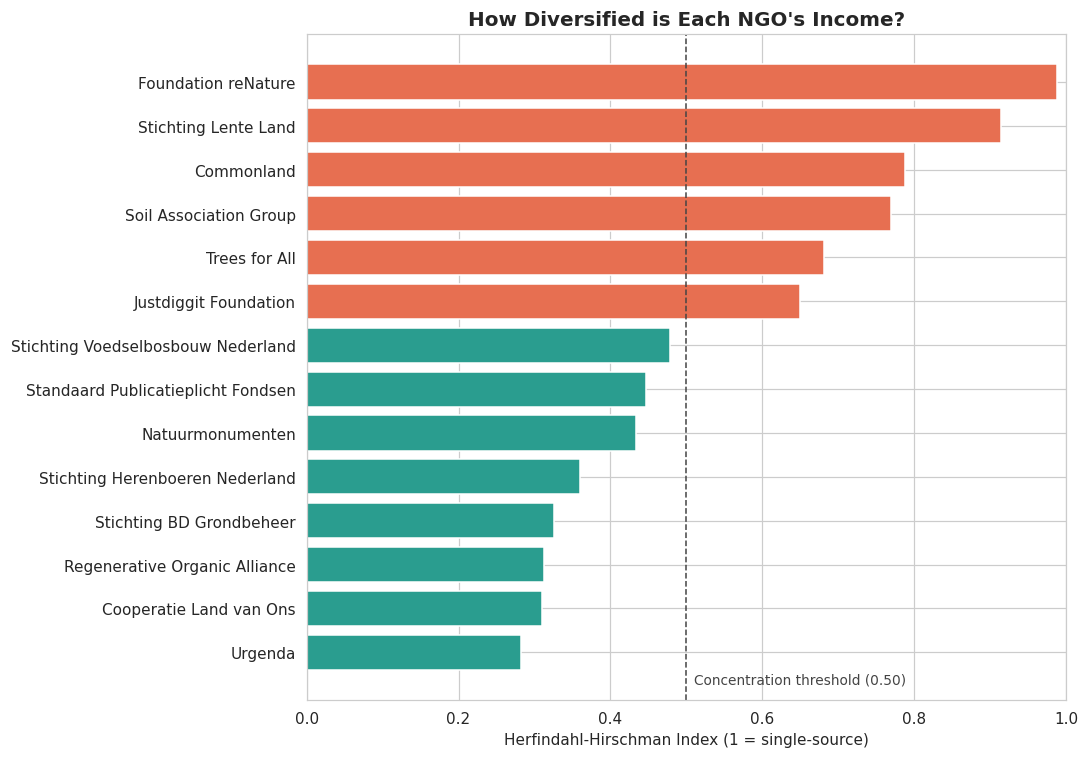


6 of 14 NGOs (43%) are highly concentrated (HHI > 0.50)


,ngo_name,hhi,concentration_flag,dominant_source,dominant_share
0,Urgenda,0,Diversified,donation,0
1,Cooperatie Land van Ons,0,Diversified,capital,0
2,Regenerative Organic Alliance,0,Diversified,community_engagement,0
3,Stichting BD Grondbeheer,0,Diversified,community_engagement,0
4,Stichting Herenboeren Nederland,0,Diversified,community_engagement,0
5,Natuurmonumenten,0,Diversified,government,1
6,Standaard Publicatieplicht Fondsen,0,Diversified,capital,1
7,Stichting Voedselbosbouw Nederland,0,Diversified,business,1
8,Justdiggit Foundation,1,High concentration,business,1
9,Trees for All,1,High concentration,business,1


In [8]:
hhi = (mix_share ** 2).sum(axis=1).sort_values()
hhi_df = hhi.reset_index()
hhi_df.columns = ["ngo_name", "hhi"]
hhi_df["concentration_flag"] = np.where(hhi_df["hhi"] > 0.50, "High concentration", "Diversified")
hhi_df["dominant_source"] = mix_share.idxmax(axis=1).reindex(hhi_df["ngo_name"]).values
hhi_df["dominant_share"] = mix_share.max(axis=1).reindex(hhi_df["ngo_name"]).values

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2A9D8F" if h <= 0.5 else "#E76F51" for h in hhi_df["hhi"]]
ax.barh(hhi_df["ngo_name"], hhi_df["hhi"], color=colors)
ax.axvline(0.5, color="#444", linestyle="--", linewidth=1)
ax.text(0.51, -0.7, "Concentration threshold (0.50)", fontsize=9, color="#444")
ax.set_xlabel("Herfindahl-Hirschman Index (1 = single-source)")
ax.set_title("How Diversified is Each NGO's Income?", fontsize=13, weight="bold")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("visualizations/04_diversification_hhi.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{(hhi_df['hhi'] > 0.5).sum()} of {len(hhi_df)} NGOs ({(hhi_df['hhi']>0.5).mean():.0%}) are highly concentrated (HHI > 0.50)")
hhi_df


**Insight.** A majority of comparable NGOs are *highly concentrated* — they depend on one source for more than half their income. This means:

1. **Diversification is harder than it sounds.** Most successful NGOs in this space have not achieved it. Funding tends to consolidate around the channel that works.
2. **The "dominant source" question matters more than diversification per se.** The strategic question is *which channel to anchor on*, then add complementary streams.
3. **For RAAP!, "diversified" should be reframed.** Instead of an even 5-way split, target 1 anchor source (~50%) + 2-3 secondary streams (~15-20% each).


## 6. Which Source Dominates Most Often?

If most NGOs anchor on one source, *which one* is most commonly the anchor?


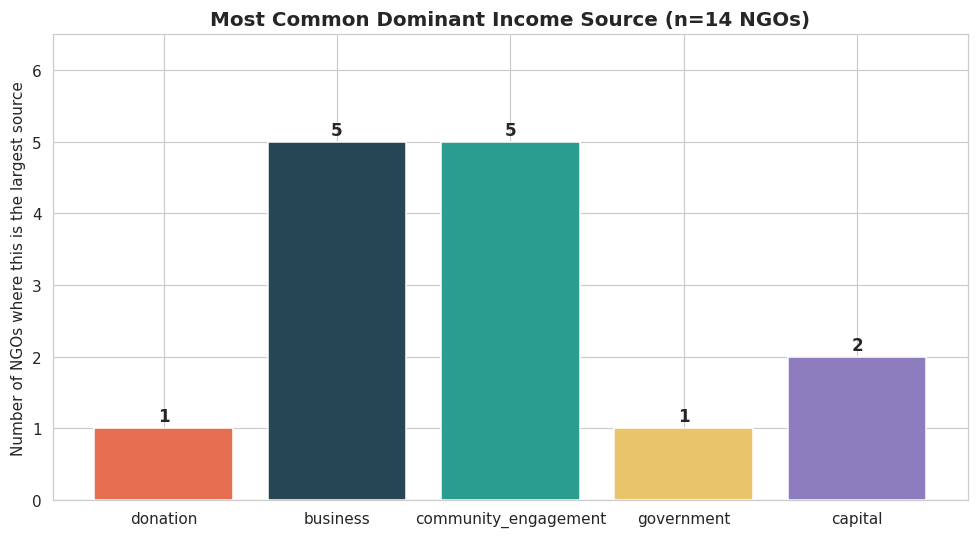

In [9]:
dominant_counts = hhi_df["dominant_source"].value_counts().reindex(CATEGORY_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dominant_counts.index, dominant_counts.values,
              color=[CATEGORY_COLORS[c] for c in dominant_counts.index])
for bar, val in zip(bars, dominant_counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha="center", fontsize=11, weight="bold")
ax.set_ylabel("Number of NGOs where this is the largest source")
ax.set_title("Most Common Dominant Income Source (n=14 NGOs)",
             fontsize=13, weight="bold")
ax.set_ylim(0, dominant_counts.max() + 1.5)
plt.tight_layout()
plt.savefig("visualizations/05_dominant_source.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight.** *Business* and *community engagement* are the two most common dominant sources, almost equally split. The business channel anchors larger NGOs; community engagement anchors smaller ones. **Donation** is rarely the largest source — only 1-2 NGOs anchor on individual giving.

## 7. Source Coverage Heatmap

Which NGOs are *touching* which channels? A non-zero share signals at least some activity in that source.


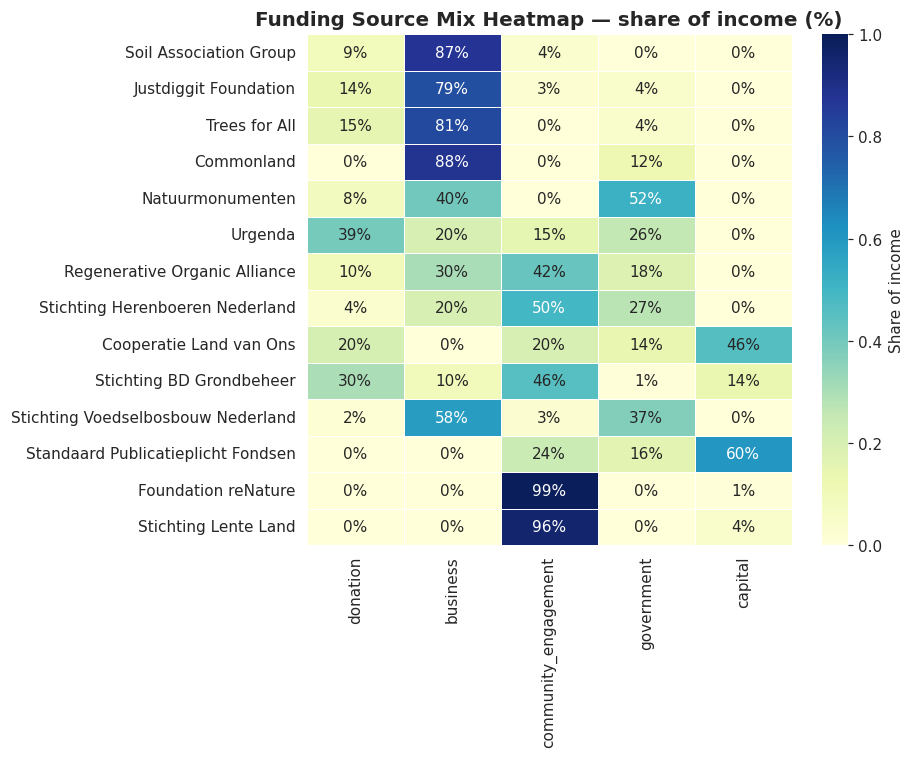

In [10]:
# Sort by total income desc
heatmap_data = mix_share.loc[mix["total"].sort_values(ascending=False).index]
heatmap_data = heatmap_data[CATEGORY_ORDER]

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".0%", cmap="YlGnBu",
            cbar_kws={"label": "Share of income"}, linewidths=0.5,
            linecolor="white", ax=ax, vmin=0, vmax=1)
ax.set_title("Funding Source Mix Heatmap — share of income (%)",
             fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("visualizations/06_mix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight.** Few NGOs are active across all 5 channels. The most-diversified NGOs (BD Grondbeheer, Land van Ons, Stichting Herenboeren) are present in 4-5 categories — these are the **diversification role models** for RAAP! to study. They tend to combine community engagement (member/farmer income), donations, and government grants — not corporate-led.

## 8. Strategic Implications for RAAP!

Connecting the data findings back to the opportunities RAAP! identified in the project deck.

### 8.1 RAAP!'s Stated Opportunities — Mapped to the Data

| RAAP! Opportunity (from slide 7) | Data-backed channel | Verdict |
|---|---|---|
| **ANBI status** with Dutch tax authorities | Unlocks the **donation** category (tax-deductible giving) | High-impact prerequisite — but donation is rarely the *largest* channel for peer NGOs (~1 in 14). Pursue ANBI as enabler, not anchor. |
| **Voluntary Carbon Market (VCM)** — selling credits to US companies | New form of **business** income | Aligns with the dominant channel for large NGOs. *This is the strategic bet.* No NGO in the benchmark has cracked this yet — first-mover opportunity. |
| **EU Green Deal** subsidies | **Government** category | Multiple peers tap this. Realistic to target 15-25% of income from EU/national grants. |
| **Growing organic / regenerative market** | **Business** category (corporate sponsors, B2B sales) | Aligns with what works at scale. RAAP!'s "Marketing & Distribution" service is the right vehicle. |

### 8.2 Recommended Funding Mix Targets for RAAP!

Based on the size-band analysis, here is a **staged target** mix as RAAP! grows from <€1M → €5M+:


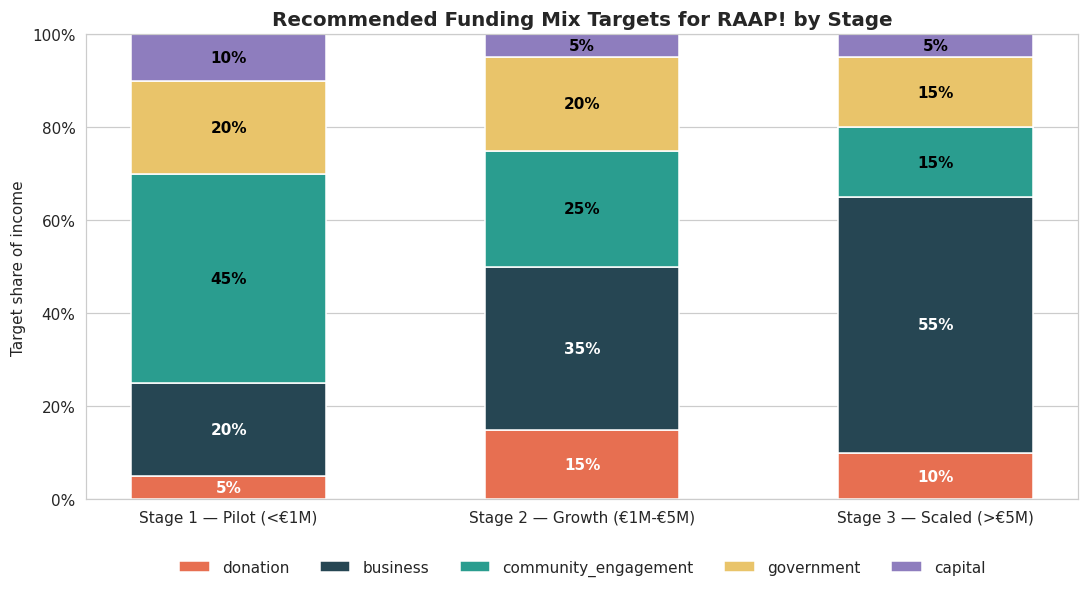


Target mix (%):
                      Stage 1 — Pilot (<€1M)  Stage 2 — Growth (€1M-€5M)  \
donation                                   5                          15   
business                                  20                          35   
community_engagement                      45                          25   
government                                20                          20   
capital                                   10                           5   

                      Stage 3 — Scaled (>€5M)  
donation                                   10  
business                                   55  
community_engagement                       15  
government                                 15  
capital                                     5  


In [11]:
target_mix = pd.DataFrame({
    "Stage 1 — Pilot (<€1M)":     [0.05, 0.20, 0.45, 0.20, 0.10],
    "Stage 2 — Growth (€1M-€5M)": [0.15, 0.35, 0.25, 0.20, 0.05],
    "Stage 3 — Scaled (>€5M)":    [0.10, 0.55, 0.15, 0.15, 0.05],
}, index=CATEGORY_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(target_mix.columns))
for cat in CATEGORY_ORDER:
    ax.bar(target_mix.columns, target_mix.loc[cat],
           bottom=bottom, color=CATEGORY_COLORS[cat], label=cat, width=0.55)
    bottom += target_mix.loc[cat].values

# Add percentage labels
for i, col in enumerate(target_mix.columns):
    cum = 0
    for cat in CATEGORY_ORDER:
        share = target_mix.loc[cat, col]
        if share >= 0.05:
            ax.text(i, cum + share/2, f"{share:.0%}",
                    ha="center", va="center",
                    color="white" if cat in ("business", "donation") else "black",
                    fontsize=10, weight="bold")
        cum += share

ax.set_ylabel("Target share of income")
ax.set_title("Recommended Funding Mix Targets for RAAP! by Stage",
             fontsize=13, weight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=5, frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("visualizations/07_raap_target_mix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTarget mix (%):")
print((target_mix * 100).round(0).astype(int))


### 8.3 Answering RAAP!'s Question: *Is VC funding feasible?*

The deck asks: *"Do you think it is feasible to raise funds from VCs for this NGO?"*

**Data-driven answer: not directly, but adjacent paths work.**

- **Zero of 14** benchmark NGOs report income from venture capital. NGOs are not the right vehicle for VC capital — VCs require equity stakes and a return profile that a non-profit cannot legally provide.
- **However**, the *spirit* of the question — attracting growth capital from sophisticated, climate-aligned investors — is exactly what the **business** category captures: foundations like Stichting DOEN, corporate sponsors like Greenchoice, climate-focused private donors. These are the "VCs of the non-profit world."
- A more promising adjacent path: a **hybrid structure** — a non-profit RAAP! Foundation alongside a for-profit RAAP! BV that handles regenerative project investment. The for-profit arm could attract VC; the foundation channels grants and donations. Several models exist (Justdiggit's commercial partnerships, Commonland's project-finance approach).

### 8.4 Most Effective Fundraising Channels in the Netherlands

From the data, ranked by frequency-of-use among peer NGOs:

1. **Postcode Loterij / Lottery organizations** — appears in the largest NGOs (Natuurmonumenten €3.5M, Trees for All €400K, Commonland €1.1M). High-impact but selective: requires multi-year track record.
2. **Foundation grants** — Stichting DOEN, WWF, Goeie Grutten appear repeatedly. Low-friction entry channel for early-stage NGOs.
3. **Government grants** — RVO, Ministry of LNV, Waterschappen (water authorities). Project-specific, requires proposal writing capacity.
4. **Corporate sponsorships** — Greenchoice, Dille & Kamille, etc. Aligns with regenerative branding.
5. **Member contributions / community fees** — high effort, builds long-term resilience (Land van Ons has 26,000+ members).


## 9. Limitations

- **Sample size** — 14 NGOs is enough for directional patterns but not statistical significance. Larger benchmarks (50+) would strengthen the analysis.
- **Categorization judgment** — some income lines were borderline (e.g. "non-profit organizations" classified as business — could arguably be donation). Sensitivity analysis with alternative classifications would test robustness.
- **Year mismatch** — most data is 2023, but reNature is 2022 and ROA is 2024. Funding mixes can shift year-on-year.
- **Currency conversion** — fixed 2023 average rates used. Real-world conversions vary by transaction date.
- **Dataset bias** — NGOs were selected based on availability of public reports, which biases toward larger, more established organizations.

## 10. Next Steps

- Expand the benchmark to 30+ NGOs to strengthen the size-band analysis
- Track funding mix evolution over 3-5 years (panel data) to test the "scaling path" hypothesis
- Survey RAAP!'s existing donor base to validate which channels resonate with their narrative
- Build an interactive dashboard (Streamlit / Power BI) for the RAAP! team to explore peer mixes by region and theme

---

*Project repo: github.com/<your-username>/RAAP-Fundraising-Analysis*
